In [15]:
# Integration: call optimized training (full run requested)
import importlib.util
from pathlib import Path
# workspace root (absolute)
root = Path('/Users/ankur/Documents/GitHub/data_science')
mod_path = (root / 'BITS_ML_Project' / 'NLP' / 'optimized_train.py').resolve()
print('Loading module from', mod_path)
spec = importlib.util.spec_from_file_location('optimized_train', str(mod_path))
optimized = importlib.util.module_from_spec(spec)
spec.loader.exec_module(optimized)
train = optimized.train

artifacts = train(data_path=str(root / 'BITS_ML_Project' / 'NLP' / 'train-v1.1.json'), max_samples=20000, epochs=15, batch_size=128, save_dir=str(root / 'BITS_ML_Project' / 'NLP' / 'output'))
model = artifacts['model']
encoder_tokenizer = artifacts['encoder_tokenizer']
decoder_tokenizer = artifacts['decoder_tokenizer']
print('Integration run finished. Model:', model.name)


Loading module from /Users/ankur/Documents/GitHub/data_science/BITS_ML_Project/NLP/optimized_train.py


Model: "optimized_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ context_input       │ (None, 208)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_input      │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 17, 64)    │  1,280,000 │ context_input[0]… │
│ (Embedding)         │                   │            │ question_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 17)        │          0 │ question_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 208)       │          0 │ context_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_bilstm     │ (None, 17, 128)   │     66,048 │ encoder_embeddin… │
│ (Bidirectional)     │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_bilstm      │ (None, 208, 128)  │     66,048 │ encoder_embeddin… │
│ (Bidirectional)     │                   │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_pool       │ (None, 128)       │          0 │ question_bilstm[… │
│ (GlobalAveragePool… │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_repeat     │ (None, 208, 128)  │          0 │ question_pool[0]… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_10      │ (None, 208, 1)    │          0 │ not_equal_9[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_10       │ (None, 208, 128)  │          0 │ context_bilstm[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_10       │ (None, 208, 128)  │          0 │ expand_dims_10[0… │
│ (LogicalOr)         │                   │            │ zeros_like_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_2         │ (None, 208, 128)  │          0 │ question_repeat[… │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 208, 256)  │          0 │ logical_or_10[0]… │
│ (Concatenate)       │                   │            │ ones_like_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 9, 64)     │    512,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 9)         │          0 │ decoder_input[0]

 Total params: 4,111,936 (15.69 MB)

 Trainable params: 4,111,936 (15.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 909ms/step - loss: 5.2360
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - loss: 4.2941
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - loss: 4.1056
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - loss: 3.8972
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - loss: 3.7452
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - loss: 3.6267
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - loss: 3.5149
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - loss: 3.3996
Epoch 9/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - loss: 3.2790
Epoch 10/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - loss: 3.1612
Epoch 11/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - loss: 3.0339
Epoch 12/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - loss: 2.9096
Epoch 13/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - loss: 2.7747
Epoch 14/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - loss: 2.6358
Epoch 15/15
157/157 ━━━━━━━━━━━━━━━━━━━━

In [16]:
# Load saved artifacts from optimized training
import pickle
from tensorflow.keras.models import load_model
with open('output/encoder_tokenizer.pkl','rb') as f:
    encoder_tokenizer = pickle.load(f)
with open('output/decoder_tokenizer.pkl','rb') as f:
    decoder_tokenizer = pickle.load(f)
model = load_model('output/optimized_model.keras')
print('Loaded saved model into notebook:', model.name)


Loaded saved model into notebook: optimized_seq2seq


# NLP Assignment PS6 S2 2025
## Reading Comprehension Question Answering using an Attention-based Encoder-Decoder

**Dataset:** SQuAD v1.1 (`train-v1.1.json`)

This notebook completes all three tasks: nested JSON parsing, preprocessing and tokenization, attention-based Seq2Seq QA training, evaluation, error analysis, and architectural comparison. Run cells in order.

> **Runtime note:** A full Seq2Seq model over all SQuAD examples is expensive. `MAX_SAMPLES` is set to 20,000 by default; increase it if hardware permits. The assignment requires 15–20 epochs, so the default is 15.


## 1. Setup
Place `train-v1.1.json` in the same folder as this notebook, or update `DATA_PATH` below. Install missing packages using `pip install tensorflow pandas scikit-learn matplotlib nltk`.

In [29]:
import json
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Concatenate,
    AdditiveAttention, TimeDistributed
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

DATA_PATH = "train-v1.1.json"
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

MAX_SAMPLES = 20000
EPOCHS = 15
BATCH_SIZE = 128
EMBEDDING_DIM = 128
LATENT_DIM = 128

print("TensorFlow version:", tf.__version__)
print("Dataset path:", DATA_PATH)


TensorFlow version: 2.20.0
Dataset path: train-v1.1.json


## Task 1 — Parsing Nested Data and Sequence Preprocessing

### 1.1 Parse the nested SQuAD JSON
Each SQuAD article contains paragraphs; each paragraph contains multiple question-answer entries. We flatten it into one row per question-answer pair using the first annotated answer.

**Observation:** Flattening preserves the relationship between a context, its question, and an extractive ground-truth answer. This is the appropriate tabular format for model training.

In [30]:
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Download SQuAD v1.1 and place train-v1.1.json beside this notebook."
    )

with open(DATA_PATH, "r", encoding="utf-8") as f:
    squad = json.load(f)

records = []
for article in squad["data"]:
    title = article.get("title", "")
    for paragraph in article.get("paragraphs", []):
        context = paragraph.get("context", "")
        for qa in paragraph.get("qas", []):
            answers = qa.get("answers", [])
            if answers:
                records.append({
                    "title": title,
                    "context": context,
                    "question": qa.get("question", ""),
                    "answer_text": answers[0].get("text", ""),
                    "answer_start": answers[0].get("answer_start", -1)
                })

df = pd.DataFrame(records)
print("Flattened DataFrame shape:", df.shape)
display(df.head())

Flattened DataFrame shape: (87599, 5)


,title,context,question,answer_text,answer_start
0,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,Saint Bernadette Soubirous,515
1,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,a copper statue of Christ,188
2,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,the Main Building,279
3,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is the Grotto at Notre Dame?,a Marian place of prayer and reflection,381
4,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What sits on top of the Main Building at Notre...,a golden statue of the Virgin Mary,92


### 1.2 Clean the text
Text is lowercased, excess whitespace is removed, and sentence-ending punctuation (`.`, `?`, `!`) is retained.

**Observation:** Cleaning reduces sparsity in the vocabulary while retaining punctuation that can provide sentence-boundary information.

In [31]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9.,!?';:\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["context_clean"] = df["context"].map(clean_text)
df["question_clean"] = df["question"].map(clean_text)
df["answer_clean"] = df["answer_text"].map(clean_text)

display(df[["context_clean", "question_clean", "answer_clean"]].head())

,context_clean,question_clean,answer_clean
0,"architecturally, the school has a catholic cha...",to whom did the virgin mary allegedly appear i...,saint bernadette soubirous
1,"architecturally, the school has a catholic cha...",what is in front of the notre dame main building?,a copper statue of christ
2,"architecturally, the school has a catholic cha...",the basilica of the sacred heart at notre dame...,the main building
3,"architecturally, the school has a catholic cha...",what is the grotto at notre dame?,a marian place of prayer and reflection
4,"architecturally, the school has a catholic cha...",what sits on top of the main building at notre...,a golden statue of the virgin mary


### 1.3 Analyze token-length distributions
For this notebook, sequence length means whitespace-token count. The 95th percentile is used as the padding cutoff, balancing memory cost against context retention.

**Inference:** Contexts are expected to be substantially longer than questions and answers. Very long contexts may still be truncated, which can lead to answer errors when the relevant span falls beyond the cutoff.

,count,mean,std,min,25%,50%,75%,max
context_len,87599.0,121.139339,49.871420,20.0,90.0,111.0,144.0,660.0
question_len,87599.0,10.077775,3.566025,1.0,8.0,10.0,12.0,40.0
answer_len,87599.0,3.191361,3.413147,0.0,1.0,2.0,4.0,43.0


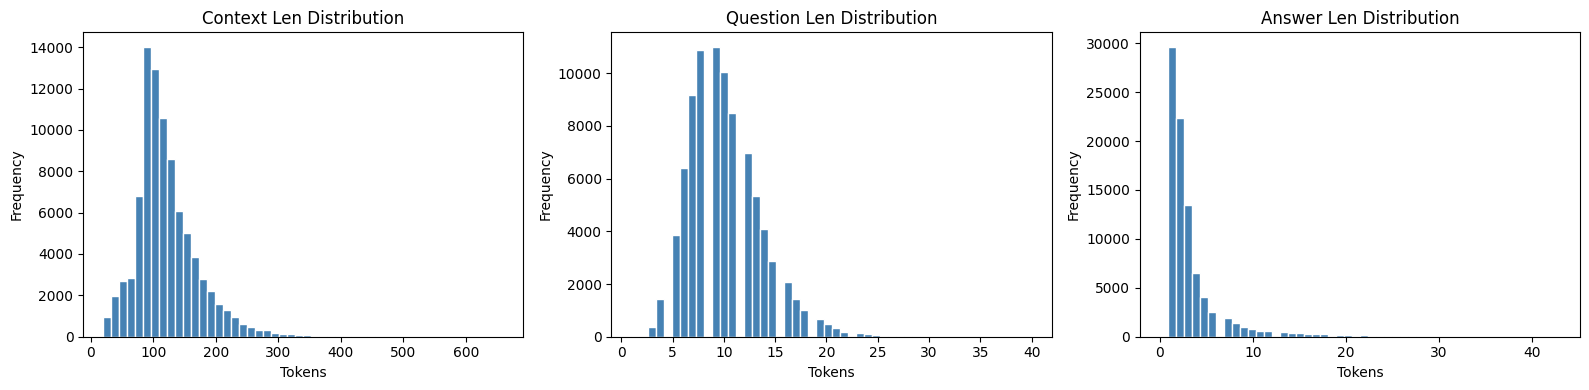

In [32]:
for col in ["context_clean", "question_clean", "answer_clean"]:
    df[col.replace("_clean", "_len")] = df[col].str.split().str.len()

length_cols = ["context_len", "question_len", "answer_len"]
display(df[length_cols].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, length_cols):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution")
    ax.set_xlabel("Tokens")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "length_distributions.png", dpi=150)
plt.show()

### 1.4 Create tokenizers and padded sequences
A shared encoder tokenizer is fitted on contexts and questions; a separate decoder tokenizer is fitted on answers. The decoder uses `<start>` and `<end>` markers for teacher forcing.

**Observation:** A shared input vocabulary lets the encoder represent words occurring in both questions and contexts. A decoder vocabulary focuses model capacity on answer generation.

In [33]:
context_maxlen = int(df["context_len"].quantile(0.95))
question_maxlen = int(df["question_len"].quantile(0.95))
answer_maxlen = int(df["answer_len"].quantile(0.95)) + 2

encoder_tokenizer = Tokenizer(oov_token="<oov>")
encoder_tokenizer.fit_on_texts(
    df["context_clean"].tolist() + df["question_clean"].tolist()
)

decoder_texts = [f"<start> {x} <end>" for x in df["answer_clean"]]
decoder_tokenizer = Tokenizer(oov_token="<oov>", filters='!"#$%&()*+,-./:;=?@[\]^_`{|}~\t\n')
decoder_tokenizer.fit_on_texts(decoder_texts)

encoder_vocab_size = len(encoder_tokenizer.word_index) + 1
decoder_vocab_size = len(decoder_tokenizer.word_index) + 1

context_seq = encoder_tokenizer.texts_to_sequences(df["context_clean"])
question_seq = encoder_tokenizer.texts_to_sequences(df["question_clean"])
answer_seq = decoder_tokenizer.texts_to_sequences(decoder_texts)

context_pad = pad_sequences(context_seq, maxlen=context_maxlen, padding="post", truncating="post")
question_pad = pad_sequences(question_seq, maxlen=question_maxlen, padding="post", truncating="post")
answer_pad = pad_sequences(answer_seq, maxlen=answer_maxlen, padding="post", truncating="post")

decoder_input_all = answer_pad[:, :-1]
decoder_target_all = answer_pad[:, 1:]

print(f"Encoder vocabulary size: {encoder_vocab_size:,}")
print(f"Decoder vocabulary size: {decoder_vocab_size:,}")
print(f"Context cutoff (95th percentile): {context_maxlen}")
print(f"Question cutoff (95th percentile): {question_maxlen}")
print(f"Answer cutoff including boundary markers: {answer_maxlen}")
print("Context padded shape:", context_pad.shape)
print("Question padded shape:", question_pad.shape)
print("Decoder input shape:", decoder_input_all.shape)
print("Decoder target shape:", decoder_target_all.shape)

<>:11: SyntaxWarning: invalid escape sequence '\]'
<>:11: SyntaxWarning: invalid escape sequence '\]'
/var/folders/qp/g8gjs5xx2937j_gh9pqg5cgc0000gn/T/ipykernel_37229/2733559377.py:11: SyntaxWarning: invalid escape sequence '\]'
  decoder_tokenizer = Tokenizer(oov_token="<oov>", filters='!"#$%&()*+,-./:;=?@[\]^_`{|}~\t\n')


Encoder vocabulary size: 85,669
Decoder vocabulary size: 38,502
Context cutoff (95th percentile): 215
Question cutoff (95th percentile): 17
Answer cutoff including boundary markers: 12
Context padded shape: (87599, 215)
Question padded shape: (87599, 17)
Decoder input shape: (87599, 11)
Decoder target shape: (87599, 11)


## Task 2 — Attention-Based Encoder-Decoder Model

### 2.1 Prepare train and validation data
A reproducible 80:20 holdout split is used. The optional sample limit is applied after preprocessing so the code remains compatible with the complete dataset.

**Inference:** A holdout validation set provides an unbiased estimate of generalization during training, while a fixed random seed makes results reproducible.

In [34]:
n_samples = min(MAX_SAMPLES, len(df))
indices = np.arange(n_samples)

train_idx, val_idx = train_test_split(indices, test_size=0.20, random_state=SEED)

ctx_tr, ctx_val = context_pad[train_idx], context_pad[val_idx]
q_tr, q_val = question_pad[train_idx], question_pad[val_idx]
dec_in_tr, dec_in_val = decoder_input_all[train_idx], decoder_input_all[val_idx]
dec_tgt_tr, dec_tgt_val = decoder_target_all[train_idx], decoder_target_all[val_idx]

print("Training examples:", len(train_idx))
print("Validation examples:", len(val_idx))

Training examples: 16000
Validation examples: 4000


### 2.2 Build the model
The context and question are encoded using a shared embedding layer and separate bidirectional LSTMs. Their token-level outputs are concatenated and passed to additive attention. The decoder predicts the next answer token at each time step.

**Observation:** Attention creates a weighted context vector for every decoder position, helping the decoder focus on relevant words from the context-question representation rather than relying only on a fixed-length vector.

In [35]:
context_input = Input(shape=(context_maxlen,), name="context_input")
question_input = Input(shape=(question_maxlen,), name="question_input")
decoder_input = Input(shape=(answer_maxlen - 1,), name="decoder_input")

encoder_embedding = Embedding(encoder_vocab_size, EMBEDDING_DIM, mask_zero=True, name="encoder_embedding")
context_emb = encoder_embedding(context_input)
question_emb = encoder_embedding(question_input)

context_encoder = Bidirectional(LSTM(LATENT_DIM, return_sequences=True), name="context_bilstm")(context_emb)
question_encoder = Bidirectional(LSTM(LATENT_DIM, return_sequences=True), name="question_bilstm")(question_emb)
encoder_outputs = Concatenate(axis=1, name="context_question_states")([context_encoder, question_encoder])

# Mean pooling gives a fixed initial state for the decoder.
initial_state = tf.keras.layers.GlobalAveragePooling1D(name="encoder_pool")(encoder_outputs)

decoder_embedding = Embedding(decoder_vocab_size, EMBEDDING_DIM, mask_zero=True, name="decoder_embedding")
dec_emb = decoder_embedding(decoder_input)
decoder_outputs = LSTM(2 * LATENT_DIM, return_sequences=True, name="decoder_lstm")(dec_emb, initial_state=[initial_state, initial_state])

attention_output = AdditiveAttention(name="attention")([decoder_outputs, encoder_outputs])
combined = Concatenate(name="decoder_attention_concat")([decoder_outputs, attention_output])
logits = TimeDistributed(Dense(decoder_vocab_size, activation="softmax"), name="token_classifier")(combined)

model = Model([context_input, question_input, decoder_input], logits, name="attention_seq2seq_qa")
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
model.summary()

Model: "attention_seq2seq_qa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ context_input       │ (None, 215)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_input      │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 17, 128)   │ 10,965,632 │ context_input[0]… │
│ (Embedding)         │                   │            │ question_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_18        │ (None, 215)       │          0 │ context_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_19        │ (None, 17)        │          0 │ question_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_bilstm      │ (None, 215, 256)  │    263,168 │ encoder_embeddin… │
│ (Bidirectional)     │                   │            │ not_equal_18[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_bilstm     │ (None, 17, 256)   │    263,168 │ encoder_embeddin… │
│ (Bidirectional)     │                   │            │ not_equal_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_20      │ (None, 215, 1)    │          0 │ not_equal_18[0][… │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_20       │ (None, 215, 256)  │          0 │ context_bilstm[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_21      │ (None, 17, 1)     │          0 │ not_equal_19[0][… │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_21       │ (None, 17, 256)   │          0 │ question_bilstm[… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_20       │ (None, 215, 256)  │          0 │ expand_dims_20[0… │
│ (LogicalOr)         │                   │            │ zeros_like_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_21       │ (None, 17, 256)   │          0 │ expand_dims_21[0… │
│ (LogicalOr)         │                   │            │ zeros_like_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 232, 256)  │          0 │ logical_or_20[0]… │
│ (Concatenate)       │                   │            │ logical_or_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_question_s… │ (None, 232, 256)  │          0 │ context_bilstm[0… │
│ (Concatenate)       │                   │            │ question_bilstm[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_12 (Any)        │ (None, 232)       │          0 │ concatenate_12[0

 Total params: 36,566,246 (139.49 MB)

 Trainable params: 36,566,246 (139.49 MB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Train for 15 epochs
Early stopping is included but configured to allow the required 15 epochs unless validation loss fails to improve for four consecutive epochs.

**Observation:** Training accuracy normally rises faster than validation accuracy. A widening loss gap indicates overfitting; restoring the best validation weights protects the final model from later degradation.

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    [ctx_tr, q_tr, dec_in_tr],
    dec_tgt_tr,
    validation_data=([ctx_val, q_val, dec_in_val], dec_tgt_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

model.save(OUTPUT_DIR / "attention_seq2seq_qa.keras")

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 115s 902ms/step - accuracy: 0.3900 - loss: 6.2079 - val_accuracy: 0.4444 - val_loss: 5.2518
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.4483 - loss: 4.8940 - val_accuracy: 0.4513 - val_loss: 5.1849
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.4527 - loss: 4.6945 - val_accuracy: 0.4518 - val_loss: 5.1576
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.4531 - loss: 4.5003 - val_accuracy: 0.4512 - val_loss: 5.1444
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.4539 - loss: 4.2954 - val_accuracy: 0.4498 - val_loss: 5.1586
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.4559 - loss: 4.0828 - val_accuracy: 0.4481 - val_loss: 5.1872
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.4608 - loss: 3.8771 - val_accuracy: 0.4474 - val_loss: 5.2145
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.4665 - loss: 3.6660 - val_a

### 2.4 Plot loss and accuracy

**Inference:** The desired pattern is declining training and validation loss. If validation loss begins increasing while training loss continues decreasing, the model is memorizing training data and requires stronger regularization, more data, or earlier stopping.

,accuracy,loss,val_accuracy,val_loss
0,0.390039,6.207898,0.444396,5.251753
1,0.448300,4.894039,0.451329,5.184939
2,0.452720,4.694508,0.451824,5.157620
3,0.453134,4.500292,0.451219,5.144445
4,0.453932,4.295367,0.449843,5.158562
5,0.455860,4.082818,0.448082,5.187204
6,0.460776,3.877113,0.447367,5.214464
7,0.466477,3.665979,0.449953,5.241822


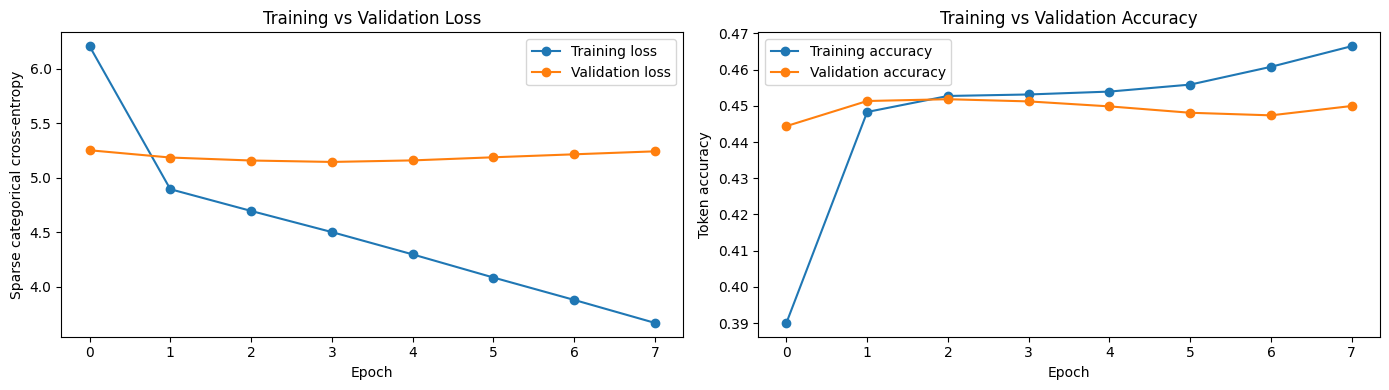

In [37]:
hist = pd.DataFrame(history.history)
display(hist)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist["loss"], marker="o", label="Training loss")
axes[0].plot(hist["val_loss"], marker="o", label="Validation loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].legend()

axes[1].plot(hist["accuracy"], marker="o", label="Training accuracy")
axes[1].plot(hist["val_accuracy"], marker="o", label="Validation accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Token accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_validation_curves.png", dpi=150)
plt.show()

### 2.5 Generate answers and evaluate EM/F1
The decoder uses greedy generation. Exact Match (EM) equals 1 only when prediction and ground truth match after normalization. Token-level F1 measures overlap between generated and reference answer tokens.

**Observation:** Token accuracy can look high because many target positions are padding. EM and token-level F1 are more meaningful QA metrics because they evaluate the generated answer text itself.

In [38]:
id_to_word = {idx: word for word, idx in decoder_tokenizer.word_index.items()}
start_id = decoder_tokenizer.word_index["start"]
end_id = decoder_tokenizer.word_index["end"]
pad_id = 0

def ids_to_answer(token_ids):
    words = []
    for token_id in token_ids:
        token_id = int(token_id)
        if token_id in (pad_id, start_id, end_id):
            continue
        word = id_to_word.get(token_id, "<oov>")
        if word != "<oov>":
            words.append(word)
    return " ".join(words).strip()

def greedy_decode(context_one, question_one, max_len=answer_maxlen - 1):
    generated = [start_id]
    for _ in range(max_len - 1):
        dec = pad_sequences([generated], maxlen=answer_maxlen - 1, padding="post")
        probabilities = model.predict([context_one[None, :], question_one[None, :], dec], verbose=0)
        next_id = int(np.argmax(probabilities[0, len(generated) - 1]))
        if next_id in (end_id, pad_id):
            break
        generated.append(next_id)
    return ids_to_answer(generated)

def normalized_tokens(text):
    return clean_text(text).split()

def exact_match(prediction, truth):
    return int(clean_text(prediction) == clean_text(truth))

def token_f1(prediction, truth):
    pred_tokens = normalized_tokens(prediction)
    truth_tokens = normalized_tokens(truth)
    if not pred_tokens and not truth_tokens:
        return 1.0
    if not pred_tokens or not truth_tokens:
        return 0.0
    common = {}
    for token in pred_tokens:
        common[token] = min(pred_tokens.count(token), truth_tokens.count(token))
    overlap = sum(common.values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(truth_tokens)
    return 2 * precision * recall / (precision + recall)

EVAL_SAMPLES = min(300, len(val_idx))
eval_indices = val_idx[:EVAL_SAMPLES]
results = []
for idx in eval_indices:
    prediction = greedy_decode(context_pad[idx], question_pad[idx])
    truth = df.iloc[idx]["answer_clean"]
    results.append({
        "row_id": int(idx),
        "question": df.iloc[idx]["question_clean"],
        "true_answer": truth,
        "predicted_answer": prediction,
        "exact_match": exact_match(prediction, truth),
        "token_f1": token_f1(prediction, truth),
        "context_was_truncated": int(df.iloc[idx]["context_len"] > context_maxlen)
    })

results_df = pd.DataFrame(results)
print(f"Validation EM on {EVAL_SAMPLES} examples: {results_df['exact_match'].mean():.4f}")
print(f"Validation token F1 on {EVAL_SAMPLES} examples: {results_df['token_f1'].mean():.4f}")
results_df.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
display(results_df.head())

Validation EM on 300 examples: 0.0000
Validation token F1 on 300 examples: 0.0160


,row_id,question,true_answer,predicted_answer,exact_match,token_f1,context_was_truncated
0,10650,huge much light does a 13 w compact fluorescen...,60 w,the the the the the the the the the the,0,0.0,0
1,2041,all of his pieces include what instrument?,piano,the the the the the the the the the the,0,0.0,0
2,8668,whitehead believed education should be the opp...,value-free school model,the the the the the the the the the the,0,0.0,0
3,1114,what percentage of the population in montana a...,6.5 percent,the the the the the the the the the the,0,0.0,0
4,13902,"in 1936, what place did bell receive on a list...",first,the the the the the the the the the the,0,0.0,0


### 2.6 Display five sample predictions

**Inference:** Predictions should be inspected qualitatively alongside numerical metrics. A low EM with a higher F1 often means the model generated a partially correct answer but missed words, word order, or answer boundaries.

In [39]:
sample_predictions = results_df.sample(min(5, len(results_df)), random_state=SEED)
display(sample_predictions[["question", "true_answer", "predicted_answer", "exact_match", "token_f1"]])
sample_predictions.to_csv(OUTPUT_DIR / "five_sample_predictions.csv", index=False)

,question,true_answer,predicted_answer,exact_match,token_f1
203,which dynasty became ruler of tibet?,the phagmodrupa dynasty,the the the the the the the the the the,0,0.153846
266,which two figures clashed over leadership of t...,lissouba and sassou,the the the the the the the the the the,0,0.000000
152,how many grammy awards did crazy in love get?,earned two grammy awards,the the the the the the the the the the,0,0.000000
9,offerings left at the muthappan temple shrine ...,bronze dog figurines,the the the the the the the the the the,0,0.000000
233,in addition to interpreting body language and ...,gesturing and pointing,the the the the the the the the the the,0,0.000000


## Task 3 — Error Analysis and Architectural Refinement

### 3.1 Analyze two incorrect or truncated predictions
The cell below automatically selects two non-exact-match examples. Review their context-truncation flag and token F1, then write the generated interpretation shown below the output into the final report.

**Error categories:**
- **Long-context truncation:** `context_was_truncated = 1`; the answer may lie beyond the retained prefix.
- **OOV issue:** rare answer words can be mapped to `<oov>`, preventing exact generation.
- **Attention misalignment:** the model predicts a plausible but wrong answer even though relevant content was retained.


In [40]:
error_examples = results_df[results_df["exact_match"] == 0].copy()
if len(error_examples) < 2:
    error_examples = results_df.copy()

error_examples = error_examples.sort_values(["context_was_truncated", "token_f1"], ascending=[False, True]).head(2)

for n, (_, row) in enumerate(error_examples.iterrows(), start=1):
    original = df.iloc[int(row["row_id"])]
    answer_tokens = set(original["answer_clean"].split())
    encoder_oov = set(encoder_tokenizer.word_index)
    oov_words = sorted([word for word in answer_tokens if word not in encoder_oov])
    print(f"\nERROR {n}")
    print("Question:", row["question"])
    print("Ground truth:", row["true_answer"])
    print("Prediction:", row["predicted_answer"])
    print("Token F1:", round(row["token_f1"], 3))
    print("Context length / cutoff:", original["context_len"], "/", context_maxlen)
    print("Context truncated:", bool(row["context_was_truncated"]))
    print("Potential answer OOV words:", oov_words if oov_words else "None detected")
    print("Context excerpt:", original["context_clean"][:700], "...")

error_examples.to_csv(OUTPUT_DIR / "two_error_examples.csv", index=False)


ERROR 1
Question: how long did yuri gagarin orbit the earth in the spacecraft?
Ground truth: 108 minutes
Prediction: the the the the the the the the the the
Token F1: 0.0
Context length / cutoff: 293 / 215
Context truncated: True
Potential answer OOV words: None detected
Context excerpt: by 1959, american observers believed that the soviet union would be the first to get a human into space, because of the time needed to prepare for mercury's first launch. on april 12, 1961, the ussr surprised the world again by launching yuri gagarin into a single orbit around the earth in a craft they called vostok 1. they dubbed gagarin the first cosmonaut, roughly translated from russian and greek as sailor of the universe . although he had the ability to take over manual control of his spacecraft in an emergency by opening an envelope he had in the cabin that contained a code that could be typed into the computer, it was flown in an automatic mode as a precaution; medical science at that ...

ERRO